In [ ]:
import pandas as pd

In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/Housing prices data analysis pro/train.csv')
df_test = pd.read_csv('/content/drive/MyDrive/Housing prices data analysis pro/test.csv')

In [ ]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
#Handle missing data :)
df_train.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [ ]:
# Calculate the threshold for missing values
threshold = 0.7 * len(df_train)

# Identify columns with more than 70% missing values
missing_columns = df_train.columns[df_train.isnull().sum() > threshold].tolist()

missing_columns

['Alley', 'PoolQC', 'Fence', 'MiscFeature']

In [ ]:
#Drop Nothing
df_train.index = df_train['Id']
df_train.drop(['Id'], axis=1, inplace=True)

In [ ]:
X = df_train.drop(['SalePrice'], axis=1)
y = df_train['SalePrice']
df_train

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Select only numerical columns
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns

# Handle missing values in numerical columns (e.g., fill with mean)
X[numerical_cols] = X[numerical_cols].fillna(X[numerical_cols].mean())
df_test[numerical_cols] = df_test[numerical_cols].fillna(X[numerical_cols].mean())

# Standardize the numerical data

scaler = StandardScaler()

X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
df_test[numerical_cols] = scaler.transform(df_test[numerical_cols])

#Get dummy variables
X = pd.get_dummies(X)
df_test = pd.get_dummies(df_test)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')


Mean Squared Error: 4278451298.959638


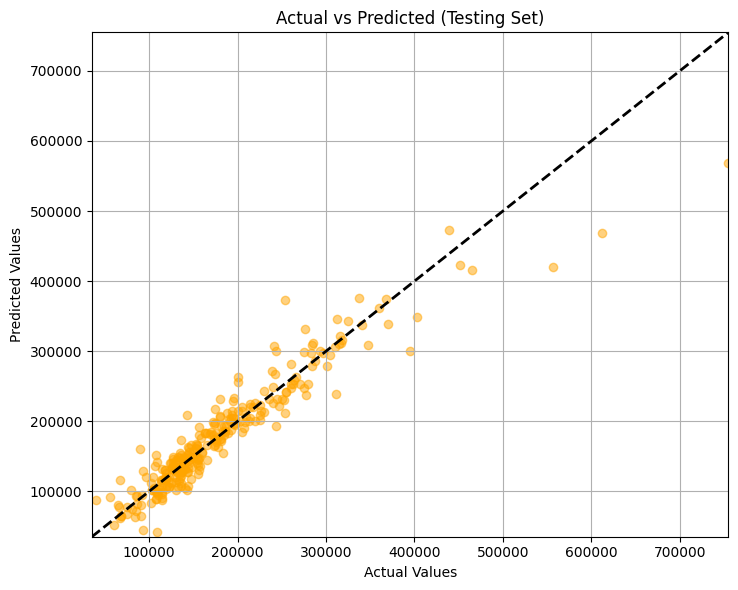

In [ ]:
import matplotlib.pyplot as plt
# Plot actual vs predicted values for training set
plt.figure(figsize=(14, 6))

# Testing set plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, color='orange', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs Predicted (Testing Set)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.xlim(y_test.min(), y_test.max())
plt.ylim(y_test.min(), y_test.max())
plt.grid()

# Show the plots
plt.tight_layout()
plt.show()

Mean Squared Error (Test): 4278451298.959638
R-squared (Test): 0.4422073868317735


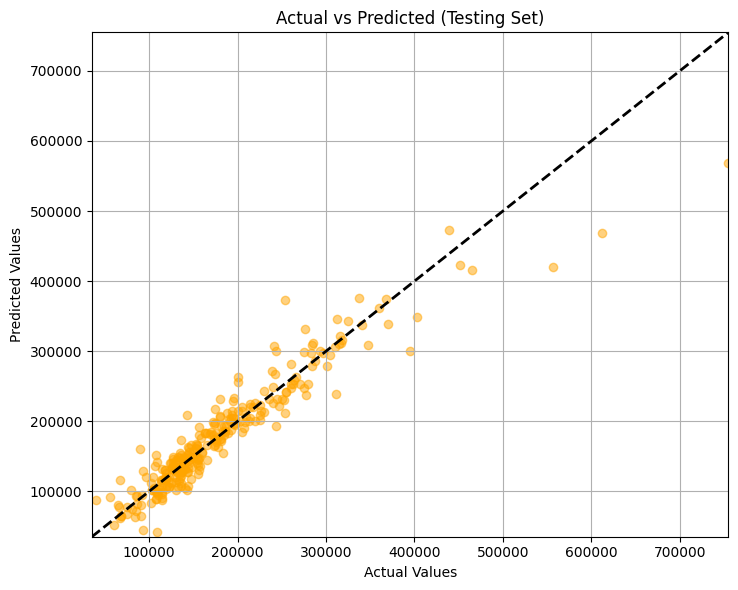

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on both training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate Mean Squared Error and R-squared
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)  # Calculate R-squared for the test set

print(f'Mean Squared Error (Test): {mse_test}')
print(f'R-squared (Test): {r2_test}')

# Plot actual vs predicted values for training set
plt.figure(figsize=(14, 6))

# Testing set plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, color='orange', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs Predicted (Testing Set)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.xlim(y_test.min(), y_test.max())
plt.ylim(y_test.min(), y_test.max())
plt.grid()

# Show the plots
plt.tight_layout()
plt.show()

In [ ]:
#Random forest regression
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 859279600.395499


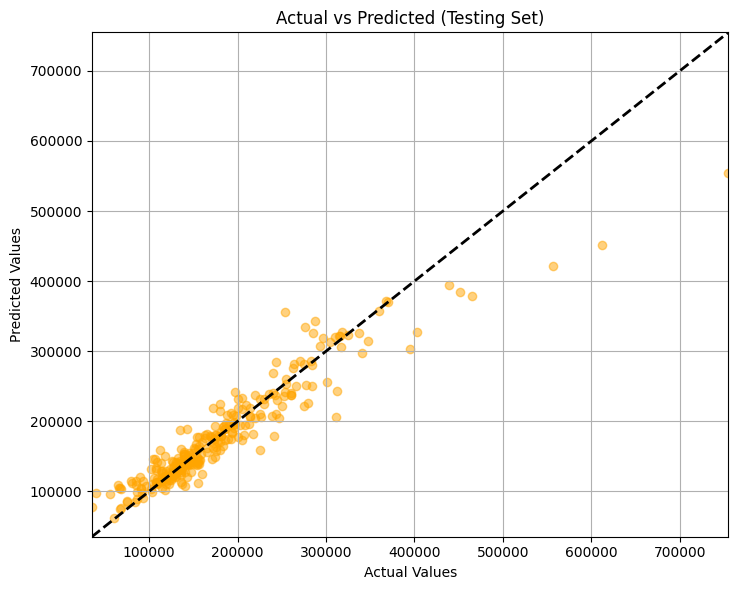

In [ ]:
import matplotlib.pyplot as plt
# Plot actual vs predicted values for training set
plt.figure(figsize=(14, 6))

# Testing set plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, color='orange', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs Predicted (Testing Set)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.xlim(y_test.min(), y_test.max())
plt.ylim(y_test.min(), y_test.max())
plt.grid()

# Show the plots
plt.tight_layout()
plt.show()

Mean Squared Error (Test): 4278451298.959638
R-squared (Test): 0.4422073868317735


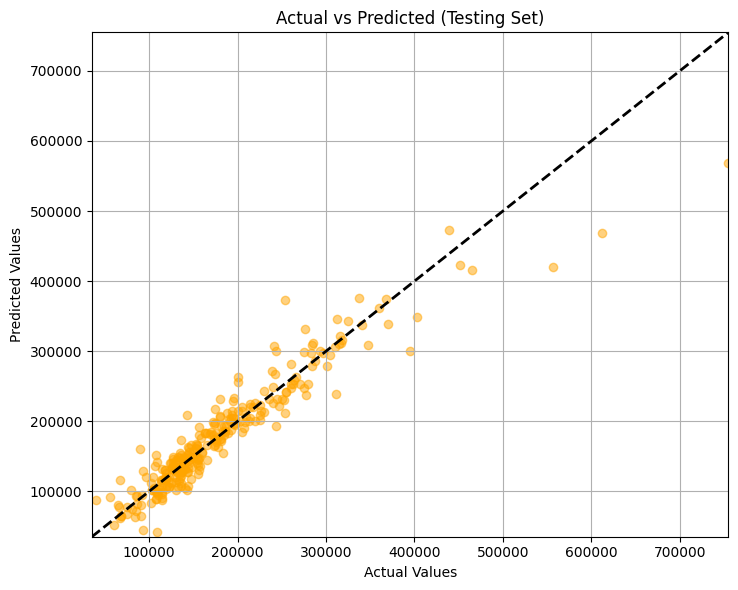

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on both training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate Mean Squared Error and R-squared
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)  # Calculate R-squared for the test set

print(f'Mean Squared Error (Test): {mse_test}')
print(f'R-squared (Test): {r2_test}')

# Plot actual vs predicted values for training set
plt.figure(figsize=(14, 6))

# Testing set plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, color='orange', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs Predicted (Testing Set)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.xlim(y_test.min(), y_test.max())
plt.ylim(y_test.min(), y_test.max())
plt.grid()

# Show the plots
plt.tight_layout()
plt.show()

In [ ]:
#XGBOOST TO THE MOON
from xgboost import XGBRegressor
model = XGBRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 665577984.0


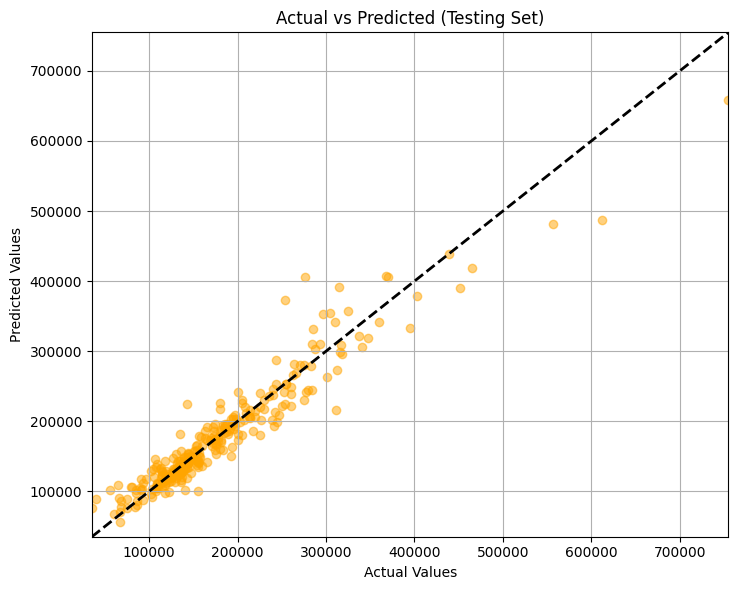

In [ ]:
import matplotlib.pyplot as plt
# Plot actual vs predicted values for training set
plt.figure(figsize=(14, 6))

# Testing set plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, color='orange', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs Predicted (Testing Set)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.xlim(y_test.min(), y_test.max())
plt.ylim(y_test.min(), y_test.max())
plt.grid()

# Show the plots
plt.tight_layout()
plt.show()

Mean Squared Error (Test): 4278451298.959638
R-squared (Test): 0.4422073868317735


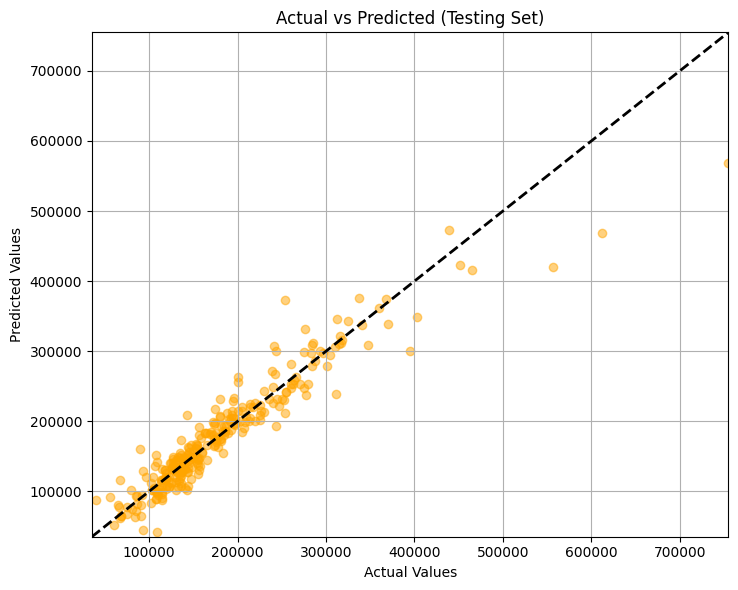

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on both training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate Mean Squared Error and R-squared
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)  # Calculate R-squared for the test set

print(f'Mean Squared Error (Test): {mse_test}')
print(f'R-squared (Test): {r2_test}')

# Plot actual vs predicted values for training set
plt.figure(figsize=(14, 6))

# Testing set plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, color='orange', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs Predicted (Testing Set)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.xlim(y_test.min(), y_test.max())
plt.ylim(y_test.min(), y_test.max())
plt.grid()

# Show the plots
plt.tight_layout()
plt.show()

NameError: name 'Juicy' is not defined